In [1]:
import warnings

warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [3]:
X_train = X_train[::100]
y_train = y_train[::100]
X_test = X_test[::100]
y_test = y_test[::100]

In [4]:
print('Shape of X_train:', X_train.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_test:', y_test.shape)

Shape of X_train: (500, 32, 32, 3)
Shape of y_train: (500, 1)
Shape of X_test: (100, 32, 32, 3)
Shape of y_test: (100, 1)


In [5]:
y_train[:5]

array([[6],
       [8],
       [6],
       [2],
       [2]], dtype=uint8)

In [6]:
numberofclass = len(np.unique(y_train))

In [7]:
y_train = to_categorical(y_train, numberofclass)
y_test = to_categorical(y_test, numberofclass)

In [8]:
y_train[:5]

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]])

In [9]:
input_shape = X_train.shape[1:]
input_shape

(32, 32, 3)

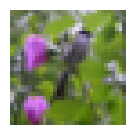

In [10]:
plt.figure(figsize=(1.5, 1.5))
plt.imshow(X_train[3].astype(np.uint8))
plt.axis('off')
plt.show()

In [11]:
#vgg19 모형에 맞게 48x48로 resize
import cv2

def resize_img(img):
    numberofimage = img.shape[0]
    new_array = np.zeros((numberofimage, 48,48,3))
    for i in range(numberofimage):
        new_array[i] = cv2.resize(img[i, :, :, :], (48,48))
    return new_array

X_train = resize_img(X_train)
X_test = resize_img(X_test)
print(X_train.shape, X_test.shape)


(500, 48, 48, 3) (100, 48, 48, 3)


In [12]:
            #top:출력층 제외
vgg = VGG19(include_top=False, weights='imagenet', input_shape=(48,48,3))
vgg.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
#transfer learning(전이학습) - 출력층만 학습
#fine tuning(미세조정) - 모든 레이어 재학습
#베테랑 택시기사는 조금만 연습하면 버스 운전도 잘 할 수 있다.  처음부터 모든 과정을 연습할 필요는 없다.

In [14]:
for layer in vgg.layers:
    layer.trainable = False

In [15]:
#vgg신경망 출력층 설정 4차원==>1차원으로 평탄화
layer = [
    layers.Flatten(),
    layers.Dense(128),
    layers.Dense(numberofclass, activation='softmax')
]

model = tf.keras.Sequential(vgg.layers + layer)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,091,338 (76.64 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [16]:
model.compile(loss='categorical_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

In [17]:
import gc  #grabage collection 쓰레기 수집
#메모리 클리어
tf.keras.backend.clear_session()
gc.collect()

0

In [18]:
hist = model.fit(X_train, y_train, validation_split=0.3, epochs=5, batch_size=1)

Epoch 1/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.2543 - loss: 19.8979 - val_accuracy: 0.3600 - val_loss: 19.3370
Epoch 2/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.5371 - loss: 9.5961 - val_accuracy: 0.3333 - val_loss: 17.8021
Epoch 3/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.7314 - loss: 5.0963 - val_accuracy: 0.4000 - val_loss: 19.2521
Epoch 4/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.7600 - loss: 3.6472 - val_accuracy: 0.3600 - val_loss: 21.2220
Epoch 5/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.8000 - loss: 2.3053 - val_accuracy: 0.3667 - val_loss: 23.1623
Epoch 6/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8371 - loss: 1.7926 - val_accuracy: 0.3267 - val_loss: 26.2743
Epoch 7/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8771 - loss: 1.3877 - val_accuracy: 0.4000 - val_loss: 25.4022
Epoch 8/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.8943 - loss: 1.0107 -

In [19]:
print(hist.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


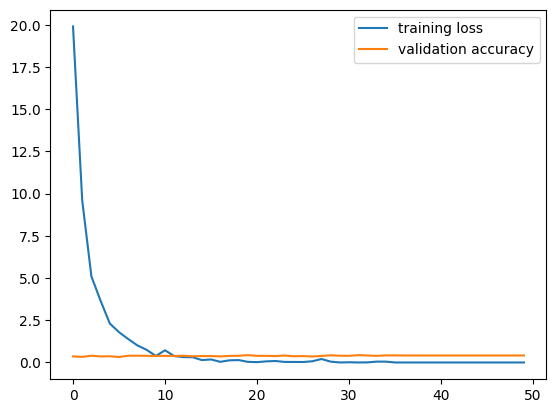

In [20]:
plt.plot(hist.history['loss'], label='training loss')
plt.plot(hist.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.show()

In [21]:
model.evaluate(X_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.3600 - loss: 28.3272


[28.327173233032227, 0.36000001430511475]